In [2]:
%pip install datasets numpy scipy matplotlib pandas --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import os

# ── CSV paths (relative to this notebook) ────────────────────────────────────
CSV_REWARD_MEAN = "wandb_export_2026-05-24T01_00_31.226-05_00.csv"   # sampling/reward_mean
CSV_TOTAL_LOSS  = "wandb_export_2026-05-24T01_00_41.194-05_00.csv"   # train/total_loss
CSV_WEIGHT_MEAN = "wandb_export_2026-05-24T01_02_05.438-05_00.csv"   # train/weight_mean
CSV_KL_LOSS     = "wandb_export_2026-05-24T01_02_10.587-05_00.csv"   # train/kl_loss
CSV_PG_LOSS     = "wandb_export_2026-05-24T14_08_38.823-05_00.csv"   # train/policy_gradient_loss

EVAL_JSON_PATH = "../eval_results/rloo_run3.json"
OUTPUT_DIR     = "."
RUN_LABEL      = "RLOO (run3)"
# ─────────────────────────────────────────────────────────────────────────────

def load_csv(path):
    df = pd.read_csv(path)
    value_col = [c for c in df.columns if c != "Step" and not c.endswith(("__MIN", "__MAX"))][0]
    return df[["Step", value_col]].rename(columns={"Step": "step", value_col: "value"})

df_reward = load_csv(CSV_REWARD_MEAN)
df_total  = load_csv(CSV_TOTAL_LOSS)
df_iw     = load_csv(CSV_WEIGHT_MEAN)
df_kl     = load_csv(CSV_KL_LOSS)
df_pg     = load_csv(CSV_PG_LOSS)

print(f"Steps in policy_gradient_loss : {len(df_pg)}")
print(f"Steps in weight_mean          : {len(df_iw)}")
print(f"Steps in kl_loss              : {len(df_kl)}")
print(f"Steps in reward_mean          : {len(df_reward)}")

Steps in policy_gradient_loss : 98
Steps in weight_mean          : 98
Steps in kl_loss              : 98
Steps in reward_mean          : 98


In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

def make_plot(df, ylabel, title, color, fname, hline=None, hline_label=None):
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.plot(df["step"], df["value"], color=color, linewidth=1.5, label=RUN_LABEL)
    if hline is not None:
        ax.axhline(hline, color="gray", linestyle="--", linewidth=1,
                   alpha=0.7, label=hline_label)
        ax.legend()
    ax.set_xlabel("Training Step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{fname}")
    plt.show()

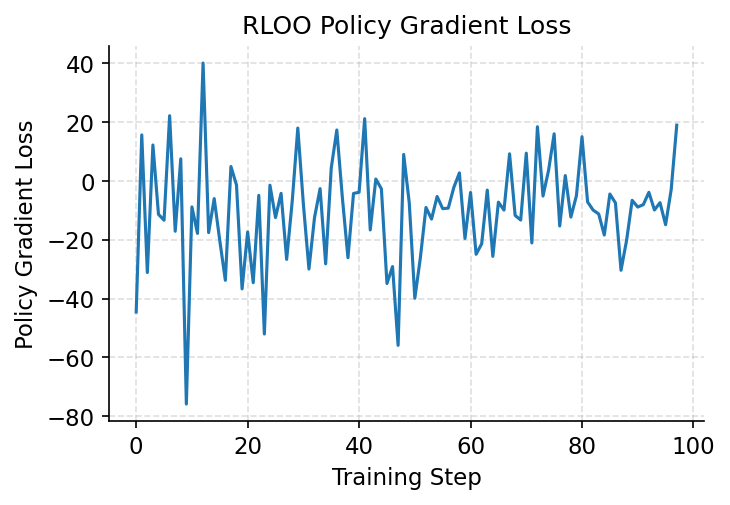

In [4]:
# ── Plot 1: RLOO Policy Gradient Loss ────────────────────────────────────────
make_plot(df_pg, "Policy Gradient Loss", "RLOO Policy Gradient Loss",
          "#1f77b4", "rloo_pg_loss.png")

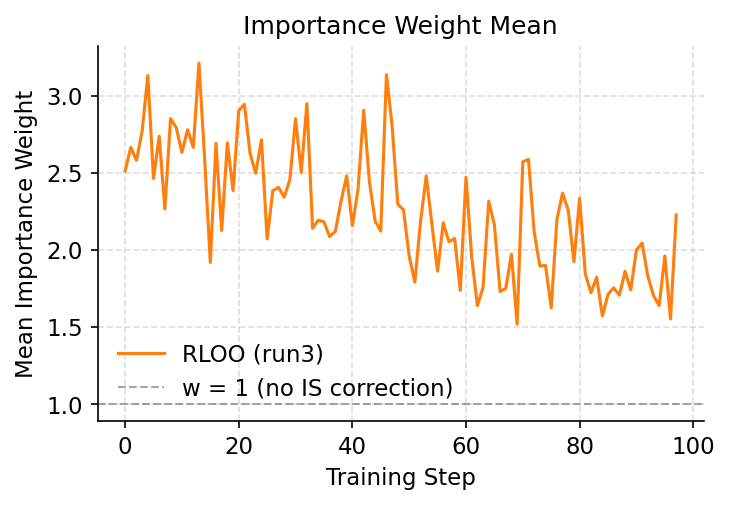

In [5]:
# ── Plot 2: Importance Weight Mean ───────────────────────────────────────────
make_plot(df_iw, "Mean Importance Weight", "Importance Weight Mean",
          "#ff7f0e", "rloo_weight_mean.png",
          hline=1.0, hline_label="w = 1 (no IS correction)")

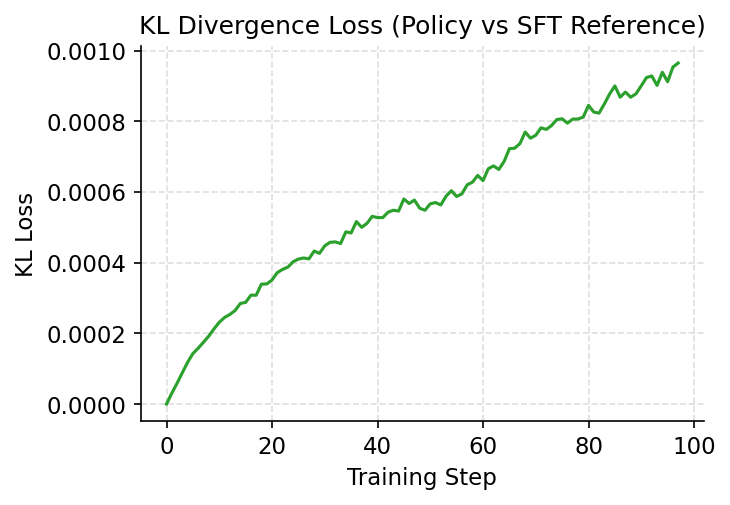

In [6]:
# ── Plot 3: KL Loss ───────────────────────────────────────────────────────────
make_plot(df_kl, "KL Loss", "KL Divergence Loss (Policy vs SFT Reference)",
          "#2ca02c", "rloo_kl_loss.png")

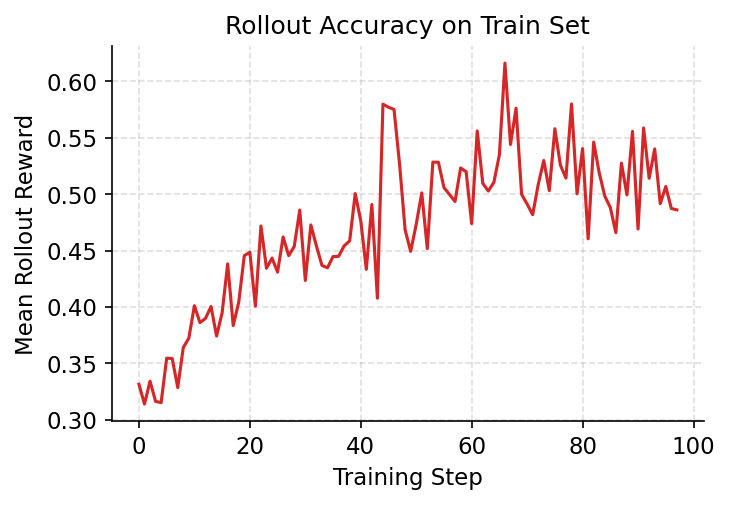

In [7]:
# ── Plot 4: Rollout Accuracy ──────────────────────────────────────────────────
make_plot(df_reward, "Mean Rollout Reward", "Rollout Accuracy on Train Set",
          "#d62728", "rloo_rollout_accuracy.png")

In [8]:
# ── Pass@k: load eval JSON ────────────────────────────────────────────────────
import datasets as hf_datasets

ds = hf_datasets.Dataset.from_json(EVAL_JSON_PATH)

def mark_correct(example):
    example["is_correct"] = [x == 1.0 for x in example["scores"]]
    return example

ds = ds.map(mark_correct, num_proc=os.cpu_count())
print(ds)

c:\Users\prani\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 50 examples [00:00, 1915.92 examples/s]
Map (num_proc=12): 100%|██████████| 50/50 [01:19<00:00,  1.60s/ examples]

Dataset({
    features: ['prompt', 'target', 'nums', 'ground_truth', 'response', 'scores', 'is_correct'],
    num_rows: 50
})


In [9]:
# ── Pass@k: computation ───────────────────────────────────────────────────────
def pass_at_k(n, c, k):
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

def compute_pass_at_k(correctness_matrix):
    n_problems, n_samples = correctness_matrix.shape
    results = []
    for k in range(1, n_samples + 1):
        per_problem = [
            pass_at_k(n_samples, int(np.sum(correctness_matrix[i])), k)
            for i in range(n_problems)
        ]
        results.append(np.mean(per_problem))
    return np.array(results)

correctness = np.array(ds["is_correct"])
pass_at_k_values = compute_pass_at_k(correctness)
k_vals = np.arange(1, len(pass_at_k_values) + 1)

for k in [1, 2, 4, 8, 16]:
    if k <= len(pass_at_k_values):
        print(f"Pass@{k:2d}: {pass_at_k_values[k-1]*100:.1f}%")

Pass@ 1: 55.1%
Pass@ 2: 66.0%
Pass@ 4: 70.6%
Pass@ 8: 71.9%
Pass@16: 72.0%


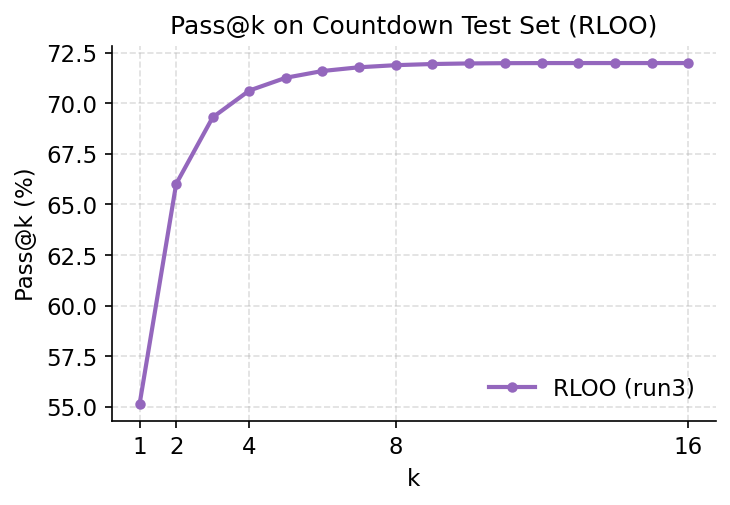

In [10]:
# ── Plot 5: Pass@k ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(k_vals, pass_at_k_values * 100, color="#9467bd",
        marker="o", markersize=4, linewidth=2, label=RUN_LABEL)
ax.set_xlabel("k")
ax.set_ylabel("Pass@k (%)")
ax.set_title("Pass@k on Countdown Test Set (RLOO)")
major = [t for t in [1, 2, 4, 8, 16] if t <= k_vals[-1]]
ax.xaxis.set_major_locator(FixedLocator(major))
ax.set_xticklabels([str(t) for t in major])
ax.legend()
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/rloo_pass_at_k.png")
plt.show()

In [ ]:
# ── Sample Rollout ────────────────────────────────────────────────────────────
df_eval = ds.to_pandas()

solved = df_eval[df_eval["is_correct"].apply(any)]
row = solved.iloc[0] if len(solved) > 0 else df_eval.iloc[0]
best_idx = next((i for i, c in enumerate(row["is_correct"]) if c), 0)

sep = "=" * 70
lines = [
    sep,
    "SAMPLE TEST-SET ROLLOUT",
    sep,
    f"Numbers : {row['nums']}",
    f"Target  : {row['target']}",
    f"Score   : {row['scores'][best_idx]}",
    "",
    "--- PROMPT ---",
    row["prompt"],
    "",
    f"--- RESPONSE #{best_idx + 1} (correct) ---",
    row["response"][best_idx],
    sep,
]
full_text = "\n".join(lines)

# Write to file so nothing is truncated
out_path = f"{OUTPUT_DIR}/sample_rollout.txt"
with open(out_path, "w", encoding="utf-8") as f:
    f.write(full_text)

print(f"Full rollout written to: {out_path}")
print(f"Prompt length  : {len(row['prompt'])} chars")
print(f"Response length: {len(row['response'][best_idx])} chars")
print(f"Numbers: {row['nums']}  |  Target: {row['target']}  |  Score: {row['scores'][best_idx]}")